In [1]:
%matplotlib inline

import os
import gc

os.environ['OPENCV_LOG_LEVEL'] = 'ERROR'

import albumentations as A
import numpy as np
from albumentations.pytorch import ToTensorV2
import cv2
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR,OneCycleLR
from torchmetrics.classification import JaccardIndex
from torchmetrics.classification import BinaryJaccardIndex, BinaryAccuracy
from torchmetrics import Accuracy
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
from skimage.morphology import binary_closing, disk
from monai.inferers import SlidingWindowInferer

In [2]:
image_size = 512
train_transform = A.Compose([
    A.RandomCrop(height=image_size, width=image_size),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Rotate(limit=25, border_mode=cv2.BORDER_CONSTANT, p=0.5),

    A.OneOf([
        A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1, p=1.0),
        A.RGBShift(r_shift_limit=20, g_shift_limit=20, b_shift_limit=20, p=1.0),
        A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=25, val_shift_limit=15, p=1.0),
    ], p=0.7),

    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.4),
    A.GaussNoise(p=0.3),
    A.MotionBlur(blur_limit=5, p=0.2),
    A.GaussianBlur(blur_limit=(3, 7), p=0.2),

    A.GridDropout(ratio=0.2, unit_size_range=(10, 50), shift_xy=(10, 10), random_offset=True, p=0.3),
    
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
], additional_targets={'mask': 'mask'})

val_transform = A.Compose([
    A.CenterCrop(height=image_size, width=image_size),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
], additional_targets={'mask': 'mask'})

test_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
], additional_targets={'mask': 'mask'})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
class SegDataset(Dataset):
    def __init__(self, image_paths, label_paths, transform=None):
        self.image_paths = image_paths
        self.label_paths = label_paths

        self.image_filenames = sorted(os.listdir(image_paths))
        self.label_filenames = sorted(os.listdir(label_paths))

        self.transform = transform

    def __getitem__(self, idx):
        image = cv2.imread(f'{self.image_paths}/{self.image_filenames[idx]}')
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(f'{self.label_paths}/{self.label_filenames[idx]}', cv2.IMREAD_GRAYSCALE)
        mask = mask / 255.0

        if self.transform:
            sample = self.transform(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']
        mask = mask.unsqueeze(0).float()
        return image, mask

    def __len__(self):
        return len(self.image_filenames)

In [4]:
class FocalIoULoss(nn.Module):
    def __init__(self, focal_weight=0.5, iou_weight=0.5, gamma=2.0):
        super().__init__()
        
        self.focal = smp.losses.FocalLoss(
            mode='binary', 
            gamma=gamma, 
            alpha=0.25, 
            normalized=True
        )
        
        self.iou = smp.losses.JaccardLoss(mode='binary')
        
        self.focal_weight = focal_weight
        self.iou_weight = iou_weight

    def forward(self, pred, target):
        focal_loss = self.focal(pred, target) * self.focal_weight
        iou_loss = self.iou(pred, target) * self.iou_weight
        
        return focal_loss + iou_loss

In [5]:
def calculate_dice(pred, target, threshold=0.5, smooth=1e-6):
    pred_binary = (pred > threshold).float()
    intersection = (pred_binary * target).sum()
    union = pred_binary.sum() + target.sum()
    dice = (2.0 * intersection + smooth) / (union + smooth)
    return dice

In [6]:
def create_loaders():
    batch_size = 24
    train_dataset = SegDataset("tiff/train","tiff/train_labels",transform=train_transform)
    val_dataset = SegDataset("tiff/val","tiff/val_labels",transform=val_transform)

    train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=16, pin_memory=True, persistent_workers=True)
    val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, num_workers=16, pin_memory=True, persistent_workers=True)

    return train_loader, val_loader

In [7]:
def create_model():
    model = smp.UnetPlusPlus(
        encoder_name="resnet50",
        encoder_weights="imagenet",
        in_channels=3,
        classes=1,
        activation=None
    )
    model = model.to(device)
    model = torch.nn.DataParallel(model)

    for param in model.module.encoder.parameters():
        param.requires_grad = False

    return model

def create_model_for_inference():
    model = smp.UnetPlusPlus(
        encoder_name="resnet50",
        encoder_weights="imagenet",
        in_channels=3,
        classes=1,
        activation=None
    )
    model = model.to(device)
    return model

In [8]:
def train(model, train_loader, val_loader, optimizer, criterion, scheduler, epochs, best_iou, number,threshold):
    best_val_iou = best_iou
    patience_counter = 0

    train_losses = []
    val_losses = []

    arr_iou = []
    arr_dice = []
    arr_accuracy = []
    
    iou_metric = BinaryJaccardIndex(threshold=threshold).to(device)
    acc_metric = BinaryAccuracy(threshold=threshold).to(device)
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch_idx, (img, label) in enumerate(train_loader):
            img, label = img.to(device, non_blocking=True), label.to(device, non_blocking=True)
                    
            optimizer.zero_grad()
            output = model(img)
            loss = criterion(output, label)
            loss.backward()
            optimizer.step()

            if number == 1:
                scheduler.step()

            train_loss += loss.item()
        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        dice_total = 0
        with torch.no_grad():
            val_loss = 0
            for img, label in val_loader:
                img, label = img.to(device, non_blocking=True), label.to(device, non_blocking=True)
                output = model(img)
                loss = criterion(output, label)
                val_loss += loss.item()
                output=torch.sigmoid(output)
                
                dice_total += calculate_dice(output, label)
                iou_metric.update(output, label)
                acc_metric.update(output, label)

            val_loss /= len(val_loader)
            val_losses.append(val_loss)
            dice = dice_total / len(val_loader)
            iou = iou_metric.compute()
            acc = acc_metric.compute()

            arr_iou.append(iou.item())
            arr_dice.append(dice.item())
            arr_accuracy.append(acc.item())         
            
            iou_metric.reset()
            acc_metric.reset()
            if number == 2:
                scheduler.step()
            print(f"epoch: {epoch}\nval loss: {val_loss:.4f}\ndice: {dice:.4f}\niou: {iou:.4f}\nacc: {acc:.4f}\n")
            if iou > best_val_iou:
                best_val_iou = iou
                patience_counter = 0
                state_dict = model.module.state_dict() if hasattr(model, 'module') else model.state_dict()
                torch.save(state_dict, 'model.pth')
                print("модель обновлена")
            else:
                patience_counter += 1
                if patience_counter == 10:
                    break

    return train_losses, val_losses, best_val_iou, arr_iou, arr_dice, arr_accuracy


In [9]:
def test(image_dir, mask_dir, threshold, inferer):
    model = create_model_for_inference()
    checkpoint = torch.load('model.pth', map_location=device)
    model.load_state_dict(checkpoint)
    model.eval()
    
    iou_metric = BinaryJaccardIndex(threshold=threshold).to(device)
    acc_metric = BinaryAccuracy(threshold=threshold).to(device)

    dice_total = 0
    
    with torch.no_grad():
        for fname in os.listdir(image_dir):
            img_path = os.path.join(image_dir, fname)
            mask_path = os.path.join(mask_dir, fname.replace('.tiff', '.tif'))
            
            img = cv2.imread(img_path, cv2.IMREAD_COLOR)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            mask = (mask > 128).astype(np.float32)

            sample = test_transform(image=img, mask=mask)
            img, mask = sample['image'].to(device), sample['mask'].unsqueeze(0).unsqueeze(0).to(device)
            
            output = inferer(inputs=img.unsqueeze(0), network=model)
            
            output=torch.sigmoid(output)

            dice_total += calculate_dice(output, mask)
            iou_metric.update(output, mask)
            acc_metric.update(output, mask)
            
            
    print("\nИтоговые метрики:")
    print(f"Dice: {dice_total/len(os.listdir(image_dir)):.4f}")
    print(f"IoU : {iou_metric.compute().item():.4f}")
    print(f"Acc : {acc_metric.compute().item():.4f}")
    
    iou_metric.reset()
    acc_metric.reset()

In [10]:
def find_optimal_threshold(val_loader, inferer, step=0.01):
    model = create_model_for_inference().to(device)
    model.load_state_dict(torch.load('model.pth', map_location=device))
    model.eval()
    
    thresholds = np.arange(0.1, 0.9 + step, step)
    metrics = {t: 0.0 for t in thresholds}

    iou_metric = BinaryJaccardIndex(threshold=0.5).to(device)
    
    with torch.no_grad():
        for img, mask in val_loader:
            img, mask = img.to(device), mask.to(device)

            prob = torch.sigmoid(inferer(inputs=img, network=model))

            if mask.dim() == 3:
                mask = mask.unsqueeze(1)
                
            for t in thresholds:
                pred_bin = (prob > t).float()
                
                iou_metric.update(pred_bin, mask)
                metrics[t] += iou_metric.compute().item()
                iou_metric.reset()
                
    n = len(val_loader)
    metrics = {t: v / n for t, v in metrics.items()}
    
    best_t = max(metrics, key=metrics.get)
    print(f"Лучший threshold для IoU: {best_t:.2f} (метрика: {metrics[best_t]:.4f})")
    return best_t

In [11]:
def loss_graph(epochs, train_loss, val_loss):
    plt.figure(figsize=(10,5))

    plt.plot(epochs, train_loss, color="green", label="train loss")
    plt.plot(epochs, val_loss, color="red", label="val loss")

    plt.xlabel("эпоха")
    plt.ylabel("loss")
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

In [12]:
def metric_graph(epochs, iou, dice, accuracy):
    plt.figure(figsize=(10,5))

    plt.plot(epochs, iou, color="green", label="iou")
    plt.plot(epochs, dice, color="red", label="dice")
    plt.plot(epochs, accuracy, color="blue", label="accuracy")

    plt.xlabel("эпоха")
    plt.ylabel("значениe")
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

In [13]:
def main():
    train_loader, val_loader = create_loaders()
    model = create_model()
    criterion = FocalIoULoss(focal_weight=0.30, iou_weight=0.70, gamma=2.0)

    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.module.parameters()), lr=1e-3)
    scheduler = OneCycleLR(
        optimizer, 
        max_lr=1e-3,
        epochs=50,
        steps_per_epoch=len(train_loader),
        pct_start=0.15,
        anneal_strategy='cos'
    )
    train_loss1, val_loss1, best_iou, arr_iou1, arr_dice1, arr_accuracy1 = train(model, train_loader, val_loader, optimizer, criterion, scheduler, epochs=50, best_iou=0, number=1, threshold=0.5)

    if hasattr(model, 'module'):
        del model.module
    
    del model, optimizer, scheduler
    gc.collect()
    del train_loader, val_loader
    gc.collect()
    torch.cuda.empty_cache()

    train_loader, val_loader = create_loaders()
    
    model = create_model()
    checkpoint = torch.load('model.pth', map_location=device)
    model.module.load_state_dict(checkpoint)
    del checkpoint
    for param in model.module.encoder.parameters():
        param.requires_grad = True

    optimizer = torch.optim.AdamW(model.module.parameters(), lr=1e-4)
    scheduler = CosineAnnealingLR(
        optimizer, 
        T_max=50,
        eta_min=1e-7
    )
    train_loss2, val_loss2, _, arr_iou2, arr_dice2, arr_accuracy2 = train(model, train_loader, val_loader, optimizer, criterion, scheduler, epochs=50, best_iou=best_iou, number=2, threshold=0.5)

    if hasattr(model, 'module'):
        del model.module
    
    del optimizer, scheduler, model, train_loader
    gc.collect()
    torch.cuda.empty_cache()

    inferer = SlidingWindowInferer(
        roi_size=(512, 512),
        sw_batch_size=8,
        overlap=0.55,
        mode="gaussian",
        padding_mode="constant"
    )
    
    threshold = find_optimal_threshold(val_loader, inferer)

    epochs = list(range(len(train_loss1+train_loss2)))
    loss_graph(epochs, train_loss1+train_loss2, val_loss1+val_loss2)
    metric_graph(epochs, arr_iou1+arr_iou2, arr_dice1+arr_dice2, arr_accuracy1+arr_accuracy2)
    
    test("tiff/test","tiff/test_labels", threshold, inferer)

epoch: 0
val loss: 0.6125
dice: 0.2431
iou: 0.1383
acc: 0.6021

модель обновлена
epoch: 1
val loss: 0.5957
dice: 0.3342
iou: 0.2006
acc: 0.7606

модель обновлена
epoch: 2
val loss: 0.5257
dice: 0.5493
iou: 0.3786
acc: 0.9309

модель обновлена
epoch: 3
val loss: 0.5026
dice: 0.4636
iou: 0.3018
acc: 0.8660

epoch: 4
val loss: 0.3772
dice: 0.6488
iou: 0.4802
acc: 0.9515

модель обновлена
epoch: 5
val loss: 0.3836
dice: 0.6280
iou: 0.4577
acc: 0.9431

epoch: 6
val loss: 0.3591
dice: 0.6594
iou: 0.4919
acc: 0.9468

модель обновлена
epoch: 7
val loss: 0.3477
dice: 0.6722
iou: 0.5063
acc: 0.9467

модель обновлена
epoch: 8
val loss: 0.3329
dice: 0.6903
iou: 0.5271
acc: 0.9565

модель обновлена
epoch: 9
val loss: 0.3294
dice: 0.6944
iou: 0.5319
acc: 0.9535

модель обновлена
epoch: 10
val loss: 0.3420
dice: 0.6782
iou: 0.5131
acc: 0.9491

epoch: 11
val loss: 0.3273
dice: 0.6963
iou: 0.5341
acc: 0.9565

модель обновлена
epoch: 12
val loss: 0.3413
dice: 0.6786
iou: 0.5135
acc: 0.9492

epoch: 13
va

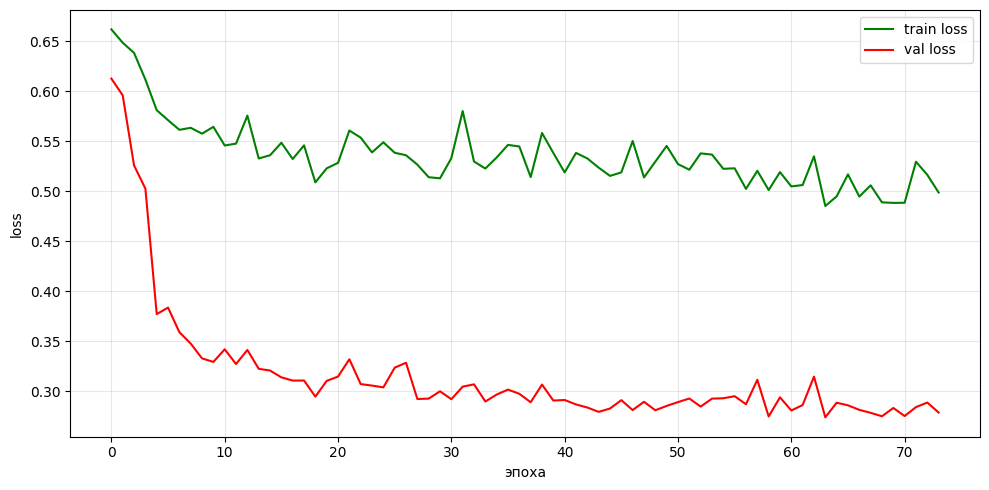

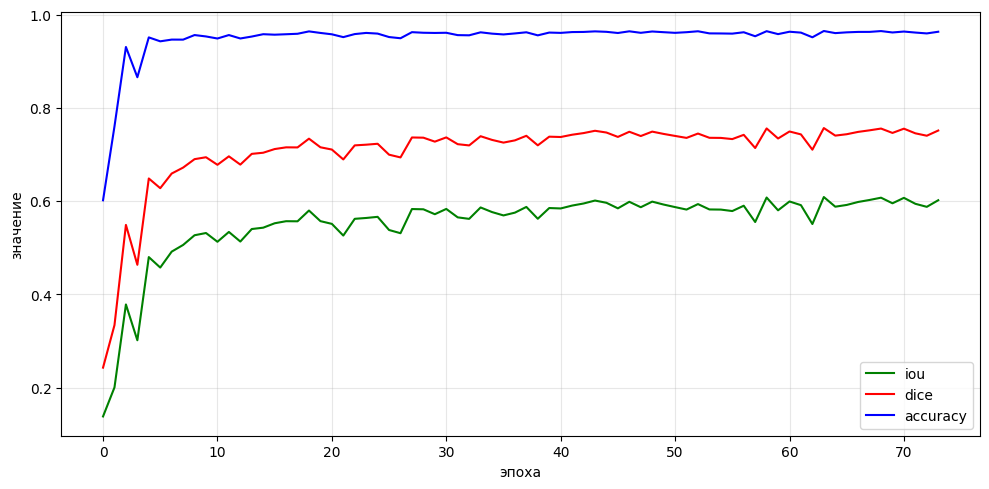

In [14]:
if __name__ == '__main__':
    main()

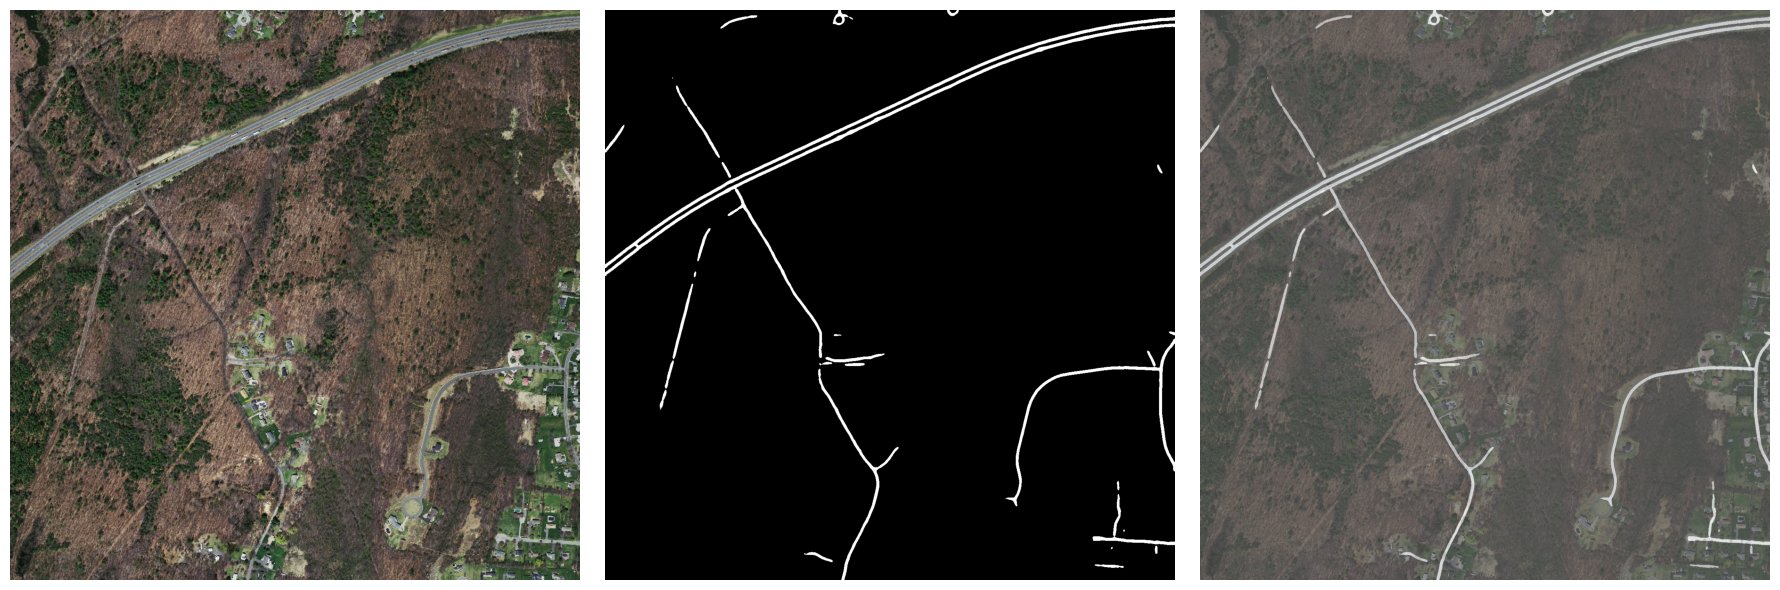

In [15]:
import matplotlib.pyplot as plt
model = create_model_for_inference()
checkpoint = torch.load('model.pth', map_location=device)
model.load_state_dict(checkpoint)
model.eval()

inferer = SlidingWindowInferer(
        roi_size=(512, 512),
        sw_batch_size=8,
        overlap=0.55,
        mode="gaussian",
        padding_mode="constant"
    )

image = cv2.imread(r'tiff/test/10378780_15.tiff')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

sample = test_transform(image=image)
image_tensor = sample['image'].unsqueeze(0).to(device)

with torch.no_grad():
    mask = (torch.sigmoid(inferer(image_tensor, network=model)) > 0.5).float()
    mask = (mask * 255).byte().squeeze(0).squeeze(0)
    mask = mask.cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(image)
axes[0].axis('off')

axes[1].imshow(mask, cmap='gray')
axes[1].axis('off')

axes[2].imshow(image, alpha=0.6)
axes[2].imshow(mask, cmap='gray', alpha=0.4)
axes[2].axis('off')

plt.tight_layout()
plt.show()

### Вывод

Изначально я пробовал модель Unet, у неё перебрал энкодеры resnet18, resnet34 и resnet50. Значение IOU было около 50%, поэтому начал изменять функцию потерь. Изначально у меня была BCE, после я пробовал: dice, iou, BCE+dice, BCE+iou. Остановился на Focalloss+iou. Ключевая метрика повысилась до 55%. После разобрался с расписаниями, почитал какие когда используются и остановился на OneCycleLR и CosineAnnealingLR, также увеличил количество эпох. Это дало ещё + 2 процента. После этого я долго не мог улучшить результат, даже попробовал DeeplabV3, но результат оставался прежним. В итоге критическая ошибка заключалась в обработке тестовых изображений, в пайплайне к ним применялся ресайз, чтобы они соответствовали размеру, который принимает модель. После удаления ресайза и добавления SlidingWindow, IOU увеличилось до 60%-63%.